In [11]:
import numpy as np
from scipy.integrate import cumulative_trapezoid, trapezoid
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

%matplotlib inline

# Cosmology using Astropy
cosmo = FlatLambdaCDM(H0=70.0, Om0=0.3)
z_grid = np.linspace(1e-4, 5.0, 8001)

# Comoving distance in Mpc
DC_Mpc = cosmo.comoving_distance(z_grid).value

# Differential comoving volume (Mpc^3 / redshift) 
# astropy differential_comoving_volume is per steradian, so multiply by 4*pi for full sky
dVc_dz = 4 * np.pi * cosmo.differential_comoving_volume(z_grid).value

DM_grid = 1000.0 * z_grid

# SFR (Madau-Dickinson)
def psi(z): return 0.015*(1+z)**2.7 / (1 + ((1+z)/2.9)**5.6)
w_SFR = psi(z_grid) / psi(0.0)

# DM smearing factor
smear = np.sqrt(1.0 + (DM_grid/1000.0)**2)

# LF and calibration
Smin_ASKAP = 1.0 * 1e-26

def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x) 

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

# Precompute the Schechter CDF for fast interpolation
L_grid_sch = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
pdf_sch = schechter_function(L_grid_sch, L_STAR, ALPHA_SCH)
cum_sch = cumulative_trapezoid(pdf_sch, L_grid_sch, initial=0.0)
norm_sch = cum_sch[-1]

D_ASKAP = 12.0
telescopes = [("D0", 12.0,  "tab:blue"),
              ("5D0",   60.0,  "tab:orange"),
              ("25D0", 300.0,  "tab:green")]

def Smin0(D): return Smin_ASKAP * (D_ASKAP/D)**2

# Bandwidth configuration for channel-by-channel intensities
BW = 300e6
nu_cen = 1.4e9
n_comp = 16
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

def p_det(z, D, alpha):
    DC_kpc = np.interp(z, z_grid, DC_Mpc) * 1000.0
    s = np.interp(z, z_grid, smear)
    
    # Calculate channel-by-channel intensity scaling factor
    nu_scaling = (nu_array / nu_cen)**alpha
    band_scaling_factor = np.mean(nu_scaling)
    
    # Calculate Lm in units of Jy * kpc^2
    # Divided by band_scaling_factor to represent the average spectral index gain/loss across the bandwidth
    Lm_Jy_kpc2 = 4*np.pi * DC_kpc**2 * (1+z)**(-1.0-alpha) * (Smin0(D)*1e26) * s / band_scaling_factor
    
    Lm_clipped = np.clip(Lm_Jy_kpc2, L_MIN_SCH, L_MAX_SCH)
    cdf_Lm = np.interp(Lm_clipped, L_grid_sch, cum_sch)
    return (norm_sch - cdf_Lm) / norm_sch

def pdf_DM(D, alpha):
    pd = p_det(z_grid, D, alpha)
    f = w_SFR * (1.0/1000.0) * (1.0/(1+z_grid)) * dVc_dz * pd
    return f / trapezoid(f, DM_grid)

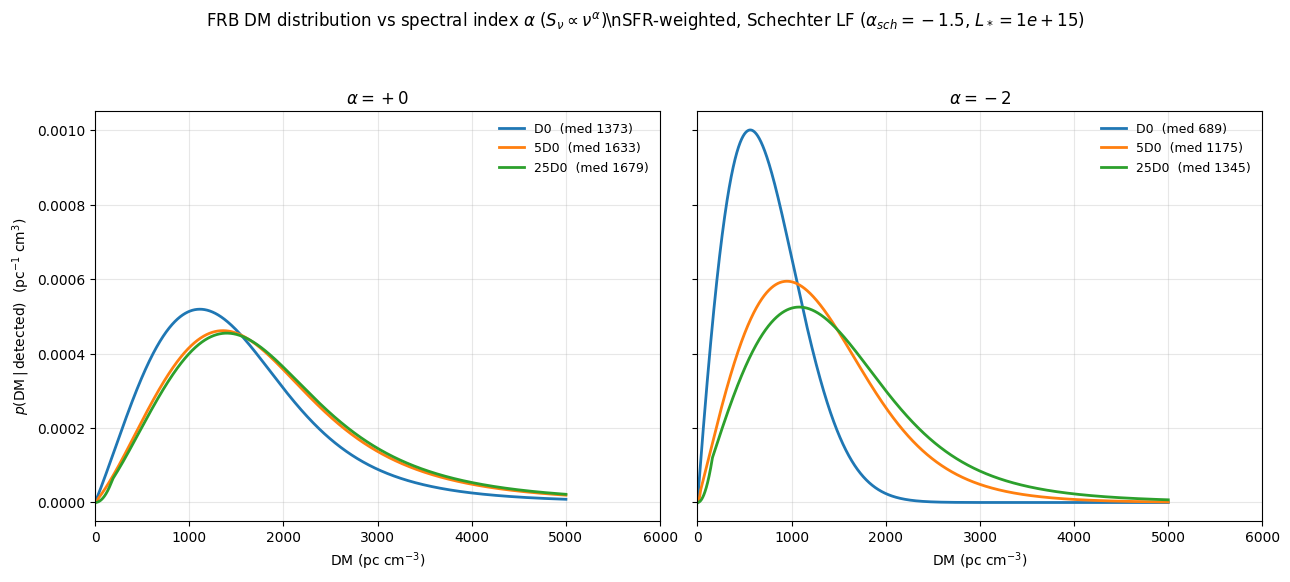

In [12]:
# --- Plot: one panel per alpha ---
alphas = [0.0, -2.0]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax, a in zip(axes, alphas):
    for name, D, col in telescopes:
        p = pdf_DM(D, a)
        cdf = cumulative_trapezoid(p, DM_grid, initial=0.0)
        med = np.interp(0.5, cdf, DM_grid)
        ax.plot(DM_grid, p, color=col, lw=2,
                label=fr"{name}  (med {med:.0f})")
    
    ax.set_xlim(0, 6000)
    ax.set_xlabel(r"DM (pc cm$^{-3}$)")
    ax.set_title(fr"$\alpha = {a:+.0f}$")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel(r"$p(\mathrm{DM}\,|\,\mathrm{detected})$  (pc$^{-1}$ cm$^3$)")
fig.suptitle(
    fr"FRB DM distribution vs spectral index $\alpha$ ($S_\nu \propto \nu^\alpha$)"
    fr"\nSFR-weighted, Schechter LF ($\alpha_{{sch}}={ALPHA_SCH}$, $L_*={L_STAR:.0e}$)",
    y=1.05)
plt.tight_layout()
plt.show()

In [13]:
# --- Quartile table ---
print("DM quartiles (pc/cm^3):")
print(f"{'telescope':8s}  {'alpha':>5s}   {'Q25':>5s} {'Q50':>5s} {'Q75':>5s} {'Q90':>5s}")
print("-" * 55)

for name, D, _ in telescopes:
    for a in alphas:
        p = pdf_DM(D, a)
        cdf = cumulative_trapezoid(p, DM_grid, initial=0.0)
        q = [np.interp(qq, cdf, DM_grid) for qq in (.25,.5,.75,.9)]
        print(f"{name:8s}  {a:+5.1f}   " + "  ".join(f"{x:5.0f}" for x in q))

DM quartiles (pc/cm^3):
telescope  alpha     Q25   Q50   Q75   Q90
-------------------------------------------------------
D0         +0.0     884   1373   1986   2689
D0         -2.0     435    689    990   1290
5D0        +0.0    1081   1633   2328   3133
5D0        -2.0     749   1175   1697   2259
25D0       +0.0    1119   1679   2387   3204
25D0       -2.0     861   1345   1949   2636
